# FastML: Multi-Class Jet Tagging

In the previous tutorial, we trained a neural network to classify jets into several physics categories. In this tutorial, we build on that model and use hls4ml to convert it into FPGA-friendly firmware. Our goal is to explore how machine learning models can be deployed in low-latency hardware while checking how well their classification performance is preserved after conversion.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nairods/Scies4Free-FastML-tutorial/blob/main/FastML.ipynb)

## 1. Import Libraries

In [ ]:
import numpy as np
import tensorflow as tf
tf.config.run_functions_eagerly(True)
import pandas as pd

from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys
!{sys.executable} -m pip install hls4ml

%matplotlib inline
RANDOM_STATE = 42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 42.7 MB/s eta 0:00:00


## 2. Load Dataset

In [ ]:
!rm -rf /content/Scies4Free-FastML-tutorial
!git clone https://github.com/nairods/Scies4Free-FastML-tutorial.git
DATA_PATH = "Scies4Free-FastML-tutorial/data/jet_tagging/"

train = np.load(DATA_PATH + "train.npz", allow_pickle=True)
val   = np.load(DATA_PATH + "val.npz", allow_pickle=True)
test  = np.load(DATA_PATH + "test.npz", allow_pickle=True)

feature_names = ['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']

X_train, y_train = train["X"], train["y"]
X_val,   y_val   = val["X"],   val["y"]
X_test,  y_test  = test["X"],  test["y"]

Cloning into 'Scies4Free-FastML-tutorial'...
remote: Enumerating objects: 524, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 524 (delta 67), reused 45 (delta 6), pack-reused 380 (from 2)
Receiving objects: 100% (524/524), 101.34 MiB | 26.21 MiB/s, done.
Resolving deltas: 100% (243/243), done.


In [ ]:
# Convert Labels to One-Hot representation
y_train = to_categorical(y_train, 5)
y_val = to_categorical(y_val, 5)
y_test = to_categorical(y_test, 5)

## 3. Load the Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
import sys
repo_path = "/content/Scies4Free-FastML-tutorial"
sys.path.insert(0, repo_path)
from callbacks import all_callbacks

In [ ]:
model = Sequential()
model.add(Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu1'))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu3'))
model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='softmax', name='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
train = False

if train:
    adam = Adam(learning_rate=1e-4)

    model.compile(
        optimizer=adam,
        loss=['categorical_crossentropy'],
        metrics=['accuracy']
    )

    callbacks = all_callbacks(
        stop_patience=1000,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir='/content/Scies4Free-FastML-tutorial/jet_models/mlp',
        model_tag='mlp'
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=1024,
        epochs=20,
        shuffle=True,
        callbacks=callbacks.callbacks,
        verbose=1
    )

else:
    model.load_weights('/content/Scies4Free-FastML-tutorial/jet_models/mlp/mlp_best.weights.h5')

## 4. Convert to FPGA Firmware with hls4ml
So far, we have trained a neural network in Keras. The next step is to turn that trained model into something that can run on an FPGA, where inference can be performed with very low latency and high parallelism.

This is what `hls4ml` does: it takes a trained model from frameworks such as Keras, translates it into HLS code, and prepares a hardware project that can be synthesized with vendor tools such as **Vitis HLS**. You can think of `hls4ml` as a compiler from neural-network layers to FPGA-oriented firmware building blocks.

When doing this, we usually cannot keep the model exactly as it was in floating-point software form. FPGA implementations often rely on fixed-point arithmetic and on-chip storage, so we first check whether the model still gives good predictions with reduced numerical precision. Then we synthesize the design and inspect hardware metrics such as latency and FPGA resource usage, which tell us how practical the design is for deployment.

### Create an hls4ml configuration and model
`hls4ml` uses a configuration dictionary to control how the software model is mapped to hardware. This configuration lets us choose things like numerical precision and the ReuseFactor, which trades off parallelism against FPGA resource usage.

In this tutorial we start with a simple configuration, which is enough to generate and test a first hardware implementation. Later, more advanced settings can be used to tune the design further for speed, size, or accuracy.

In [ ]:
import hls4ml
import plotting

config = hls4ml.utils.config_from_keras_model(model, granularity='model', backend='Vitis')
print("-----------------------------------")
print("Configuration")
plotting.print_dict(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='model_1/hls4ml_prj', part='xcvu13p-flga2577-2-e'
)

-----------------------------------
Configuration
Model
  Precision
    default:         fixed<16,6>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
-----------------------------------


Let’s visualise the converted `hls4ml` model. The diagram shows the layer structure, the shape of the data flowing between layers, and the fixed-point precisions chosen for the FPGA implementation.

This is useful because it lets us quickly verify that the conversion looks as expected and that the numerical precision is reasonable before moving on to synthesis.

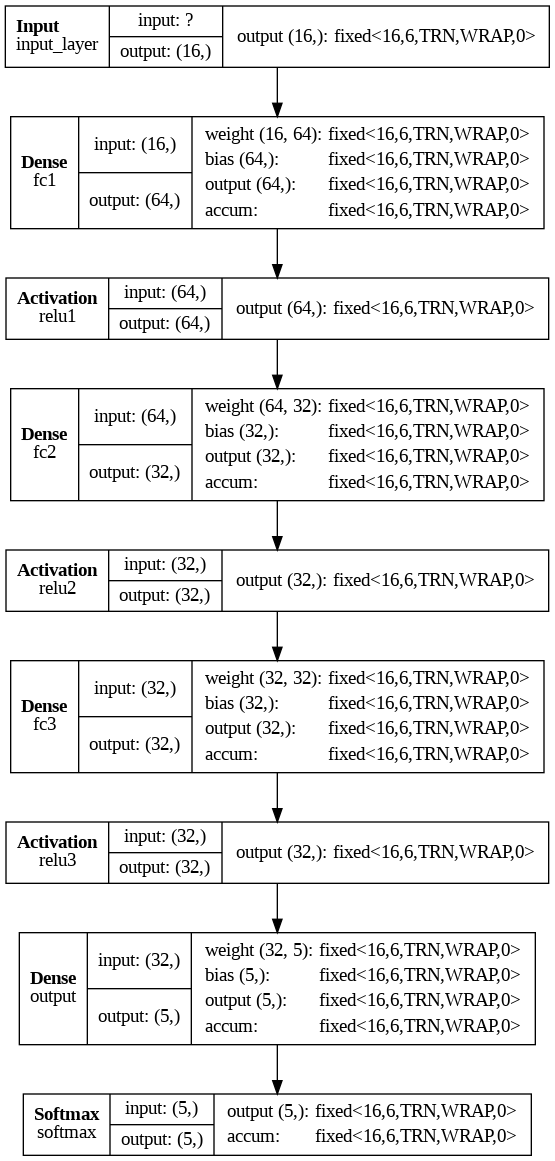

In [ ]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

## 4.1 Compile, predict
Now we need to check that this model performance is still good. We compile the hls_model, and then use `hls_model.predict` to execute the FPGA firmware with bit-accurate emulation on the CPU.

In [ ]:
hls_model.compile()
X_test = np.ascontiguousarray(X_test)
y_hls = hls_model.predict(X_test)

## 4.2 Compare
That was easy! Now let's see how the performance compares to Keras:

   1/3891 ━━━━━━━━━━━━━━━━━━━━ 8:44 135ms/step

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


3891/3891 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step
Keras  Accuracy: 0.74685140562249
hls4ml Accuracy: 0.7464578313253012


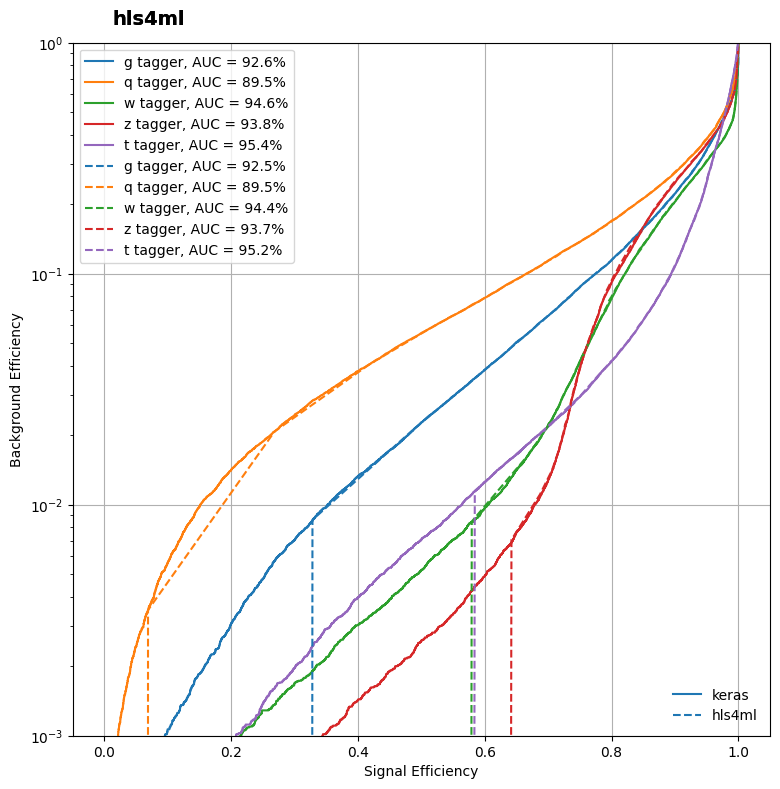

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

classes = ['g', 'q', 'w', 'z', 't']

y_score = model.predict(X_test)
print("Keras  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_score, axis=1))))
print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_score, classes)
plt.gca().set_prop_cycle(None)  # reset the colors
_ = plotting.makeRoc(y_test, y_hls, classes, linestyle='--')

from matplotlib.lines import Line2D

lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--')]
from matplotlib.legend import Legend

leg = Legend(ax, lines, labels=['keras', 'hls4ml'], loc='lower right', frameon=False)
ax.add_artist(leg)

## 5. Synthesize
In this step, we use **Vitis HLS** to synthesize the `hls4ml` model into FPGA firmware. This requires a working **Xilinx / Vitis HLS** installation with a valid license, so the build can only be run in an environment where those tools are available.

If you have such an installation, you can launch the synthesis directly from the hls_model object using the code shown below. If not, you can look at the example report outputs that are printed to illustrate what the synthesis results look like, including latency and resource usage.

After synthesis, the generated IP can be integrated into a larger workflow targeting a specific FPGA board. In this tutorial, however, we focus on inspecting the **Vitis HLS** reports rather than going through the full hardware deployment flow.

Note: This step may take several minutes when run locally with a full **Vitis HLS** setup.

In [ ]:
# hls_model.build(csim=False)

    ****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.1 964-bit)
    **** SW Build 3854077 on May 4 2023
    **** IP Build 3864474 on Sun May 7 20:36:21 MDT 2023
    **** ShareData Build 3865790 on Sun May 07 13:33:03 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.
    .
    .
    .
    INFO: [HLS 200-10] ----------------------------------------------------------------
    INFO: [HLS 200-42] -- Implementing module 'myproject'
    INFO: [HLS 200-10] ----------------------------------------------------------------
    .
    .
    .
    INFO: [HLS 200-10] ----------------------------------------------------------------
    INFO: [HLS 200-10] -- Generating RTL for module 'myproject'
    INFO: [HLS 200-10] ----------------------------------------------------------------
    .
    .
    .
    INFO: [VHDL 208-304] Generating VHDL RTL for myproject.
    INFO: [VLOG 209-307] Generating Verilog RTL for myproject.
    INFO: [HLS 200-789] **** Estimated Fmax: 236.13 MHz
    INFO: [HLS 200-111] Finished Command csynth_design CPU user time: 152.88 seconds. CPU system time: 1.29 seconds. Elapsed time: 161.08 seconds; current allocated memory: 1.339 GB.
    ***** C/RTL SYNTHESIS COMPLETED IN 0h2m41s *****


## 5.1 Check the reports
Print out the reports generated by Vitis HLS. Pay attention to the Latency and the 'Utilization Estimates' sections

In [ ]:
#hls4ml.report.read_vivado_report('model_1/hls4ml_prj/')

```text
================================================================
== Vitis HLS Report for 'myproject'
================================================================
* Date:           Fri Mar 27 11:19:05 2026

* Version:        2023.1 (Build 3854077 on May  4 2023)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcvu13p-flga2577-2-e


================================================================
== Performance Estimates
================================================================
+ Timing:
    * Summary:
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  4.235 ns|     0.62 ns|
    +--------+---------+----------+------------+

+ Latency:
    * Summary:
    +---------+---------+-----------+-----------+-----+-----+---------+
    |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
    |   min   |   max   |    min    |    max    | min | max |   Type  |
    +---------+---------+-----------+-----------+-----+-----+---------+
    |       12|       12|  60.000 ns|  60.000 ns|    1|    1|      yes|
    +---------+---------+-----------+-----------+-----+-----+---------+
```
<details>
<summary><b>Show full Vitis HLS report</b></summary>

```text
+ Detail:
        * Instance:
        +-------------------------------------------------------------------------------+------------------------------------------------------------------+---------+---------+-----------+-----------+-----+-----+---------+
        |                                                                               |                                                                  |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
        |                                    Instance                                   |                              Module                              |   min   |   max   |    min    |    max    | min | max |   Type  |
        +-------------------------------------------------------------------------------+------------------------------------------------------------------+---------+---------+-----------+-----------+-----+-----+---------+
        |grp_dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config2_s_fu_95      |dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config2_s   |        1|        1|   5.000 ns|   5.000 ns|    1|    1|      yes|
        |call_ret2_relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config4_s_fu_101   |relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config4_s       |        0|        0|       0 ns|       0 ns|    1|    1|      yes|
        |grp_dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config5_s_fu_169     |dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config5_s   |        1|        1|   5.000 ns|   5.000 ns|    1|    1|      yes|
        |call_ret4_relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config7_s_fu_237   |relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config7_s       |        0|        0|       0 ns|       0 ns|    1|    1|      yes|
        |grp_dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config8_s_fu_273     |dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config8_s   |        1|        1|   5.000 ns|   5.000 ns|    1|    1|      yes|
        |call_ret6_relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config10_s_fu_309  |relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config10_s      |        0|        0|       0 ns|       0 ns|    1|    1|      yes|
        |grp_dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config11_s_fu_345    |dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config11_s  |        1|        1|   5.000 ns|   5.000 ns|    1|    1|      yes|
        |grp_softmax_stable_ap_fixed_ap_fixed_16_6_5_3_0_softmax_config13_s_fu_381      |softmax_stable_ap_fixed_ap_fixed_16_6_5_3_0_softmax_config13_s    |        3|        3|  15.000 ns|  15.000 ns|    1|    1|      yes|
        +-------------------------------------------------------------------------------+------------------------------------------------------------------+---------+---------+-----------+-----------+-----+-----+---------+

        * Loop:
        N/A
```

</details>

```
================================================================
== Utilization Estimates
================================================================
* Summary:
+---------------------+---------+-------+---------+---------+------+
|         Name        | BRAM_18K|  DSP  |    FF   |   LUT   | URAM |
+---------------------+---------+-------+---------+---------+------+
|DSP                  |        -|      -|        -|        -|     -|
|Expression           |        -|      -|        0|        4|     -|
|FIFO                 |        -|      -|        -|        -|     -|
|Instance             |        5|   3245|    11521|   125240|     -|
|Memory               |        -|      -|        -|        -|     -|
|Multiplexer          |        -|      -|        -|       36|     -|
|Register             |        -|      -|     3423|        -|     -|
+---------------------+---------+-------+---------+---------+------+
|Total                |        5|   3245|    14944|   125280|     0|
+---------------------+---------+-------+---------+---------+------+
|Available SLR        |     1344|   3072|   864000|   432000|   320|
+---------------------+---------+-------+---------+---------+------+
|Utilization SLR (%)  |       ~0|    105|        1|       29|     0|
+---------------------+---------+-------+---------+---------+------+
|Available            |     5376|  12288|  3456000|  1728000|  1280|
+---------------------+---------+-------+---------+---------+------+
|Utilization (%)      |       ~0|     26|       ~0|        7|     0|
+---------------------+---------+-------+---------+---------+------+
                                    
```

<details>
<summary><b>Show full Vitis HLS report</b></summary>

```text
+ Detail:
    * Instance:
    +-------------------------------------------------------------------------------+------------------------------------------------------------------+---------+------+------+-------+-----+
    |                                    Instance                                   |                              Module                              | BRAM_18K|  DSP |  FF  |  LUT  | URAM|
    +-------------------------------------------------------------------------------+------------------------------------------------------------------+---------+------+------+-------+-----+
    |grp_dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config11_s_fu_345    |dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config11_s  |        0|   134|   449|   4337|    0|
    |grp_dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config2_s_fu_95      |dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config2_s   |        0|   848|  2487|  28163|    0|
    |grp_dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config5_s_fu_169     |dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config5_s   |        0|  1501|  5563|  58578|    0|
    |grp_dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config8_s_fu_273     |dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config8_s   |        0|   757|  2913|  28925|    0|
    |call_ret6_relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config10_s_fu_309  |relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config10_s      |        0|     0|     0|   1216|    0|
    |call_ret2_relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config4_s_fu_101   |relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config4_s       |        0|     0|     0|   2432|    0|
    |call_ret4_relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config7_s_fu_237   |relu_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_relu_config7_s       |        0|     0|     0|   1216|    0|
    |grp_softmax_stable_ap_fixed_ap_fixed_16_6_5_3_0_softmax_config13_s_fu_381      |softmax_stable_ap_fixed_ap_fixed_16_6_5_3_0_softmax_config13_s    |        5|     5|   109|    373|    0|
    +-------------------------------------------------------------------------------+------------------------------------------------------------------+---------+------+------+-------+-----+
    |Total                                                                          |                                                                  |        5|  3245| 11521| 125240|    0|
    +-------------------------------------------------------------------------------+------------------------------------------------------------------+---------+------+------+-------+-----+

    * DSP:
    N/A

    * Memory:
    N/A

    * FIFO:
    N/A

    * Expression:
    +---------------------------+----------+----+---+----+------------+------------+
    |       Variable Name       | Operation| DSP| FF| LUT| Bitwidth P0| Bitwidth P1|
    +---------------------------+----------+----+---+----+------------+------------+
    |ap_block_pp0_stage0_01001  |       and|   0|  0|   2|           1|           1|
    |ap_enable_pp0              |       xor|   0|  0|   2|           1|           2|
    +---------------------------+----------+----+---+----+------------+------------+
    |Total                      |          |   0|  0|   4|           2|           3|
    +---------------------------+----------+----+---+----+------------+------------+

    * Multiplexer:
    +-------------------------+----+-----------+-----+-----------+
    |           Name          | LUT| Input Size| Bits| Total Bits|
    +-------------------------+----+-----------+-----+-----------+
    |fc1_input_ap_vld_in_sig  |   9|          2|    1|          2|
    |fc1_input_ap_vld_preg    |   9|          2|    1|          2|
    |fc1_input_blk_n          |   9|          2|    1|          2|
    |fc1_input_in_sig         |   9|          2|  256|        512|
    +-------------------------+----+-----------+-----+-----------+
    |Total                    |  36|          8|  259|        518|
    +-------------------------+----+-----------+-----+-----------+

    * Register:
    +----------------------------------------------------------------------------------------+-----+----+-----+-----------+
    |                                          Name                                          |  FF | LUT| Bits| Const Bits|
    +----------------------------------------------------------------------------------------+-----+----+-----+-----------+
    |ap_CS_fsm                                                                               |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter1                                                                 |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter10                                                                |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter11                                                                |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter12                                                                |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter2                                                                 |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter3                                                                 |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter4                                                                 |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter5                                                                 |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter6                                                                 |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter7                                                                 |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter8                                                                 |    1|   0|    1|          0|
    |ap_enable_reg_pp0_iter9                                                                 |    1|   0|    1|          0|
    |fc1_input_ap_vld_preg                                                                   |    1|   0|    1|          0|
    |fc1_input_preg                                                                          |  256|   0|  256|          0|
    |grp_softmax_stable_ap_fixed_ap_fixed_16_6_5_3_0_softmax_config13_s_fu_381_ap_start_reg  |    1|   0|    1|          0|
    |layer10_out_10_reg_2377                                                                 |   16|   0|   16|          0|
    |layer10_out_11_reg_2382                                                                 |   16|   0|   16|          0|
    |layer10_out_12_reg_2387                                                                 |   16|   0|   16|          0|
    |layer10_out_13_reg_2392                                                                 |   16|   0|   16|          0|
    |layer10_out_14_reg_2397                                                                 |   16|   0|   16|          0|
    |layer10_out_15_reg_2402                                                                 |   16|   0|   16|          0|
    |layer10_out_16_reg_2407                                                                 |   16|   0|   16|          0|
    |layer10_out_17_reg_2412                                                                 |   16|   0|   16|          0|
    |layer10_out_18_reg_2417                                                                 |   16|   0|   16|          0|
    |layer10_out_19_reg_2422                                                                 |   16|   0|   16|          0|
    |layer10_out_1_reg_2332                                                                  |   16|   0|   16|          0|
    |layer10_out_20_reg_2427                                                                 |   16|   0|   16|          0|
    |layer10_out_21_reg_2432                                                                 |   16|   0|   16|          0|
    |layer10_out_22_reg_2437                                                                 |   16|   0|   16|          0|
    |layer10_out_23_reg_2442                                                                 |   16|   0|   16|          0|
    |layer10_out_24_reg_2447                                                                 |   16|   0|   16|          0|
    |layer10_out_25_reg_2452                                                                 |   16|   0|   16|          0|
    |layer10_out_26_reg_2457                                                                 |   16|   0|   16|          0|
    |layer10_out_27_reg_2462                                                                 |   16|   0|   16|          0|
    |layer10_out_28_reg_2467                                                                 |   16|   0|   16|          0|
    |layer10_out_29_reg_2472                                                                 |   16|   0|   16|          0|
    |layer10_out_2_reg_2337                                                                  |   16|   0|   16|          0|
    |layer10_out_30_reg_2477                                                                 |   16|   0|   16|          0|
    |layer10_out_31_reg_2482                                                                 |   16|   0|   16|          0|
    |layer10_out_3_reg_2342                                                                  |   16|   0|   16|          0|
    |layer10_out_4_reg_2347                                                                  |   16|   0|   16|          0|
    |layer10_out_5_reg_2352                                                                  |   16|   0|   16|          0|
    |layer10_out_6_reg_2357                                                                  |   16|   0|   16|          0|
    |layer10_out_7_reg_2362                                                                  |   16|   0|   16|          0|
    |layer10_out_8_reg_2367                                                                  |   16|   0|   16|          0|
    |layer10_out_9_reg_2372                                                                  |   16|   0|   16|          0|
    |layer10_out_reg_2327                                                                    |   16|   0|   16|          0|
    |layer11_out_1_reg_2492                                                                  |   16|   0|   16|          0|
    |layer11_out_2_reg_2497                                                                  |   16|   0|   16|          0|
    |layer11_out_3_reg_2502                                                                  |   16|   0|   16|          0|
    |layer11_out_4_reg_2507                                                                  |   16|   0|   16|          0|
    |layer11_out_reg_2487                                                                    |   16|   0|   16|          0|
    |layer2_out_10_reg_1577                                                                  |   16|   0|   16|          0|
    |layer2_out_11_reg_1582                                                                  |   16|   0|   16|          0|
    |layer2_out_12_reg_1587                                                                  |   16|   0|   16|          0|
    |layer2_out_13_reg_1592                                                                  |   16|   0|   16|          0|
    |layer2_out_14_reg_1597                                                                  |   16|   0|   16|          0|
    |layer2_out_15_reg_1602                                                                  |   16|   0|   16|          0|
    |layer2_out_16_reg_1607                                                                  |   16|   0|   16|          0|
    |layer2_out_17_reg_1612                                                                  |   16|   0|   16|          0|
    |layer2_out_18_reg_1617                                                                  |   16|   0|   16|          0|
    |layer2_out_19_reg_1622                                                                  |   16|   0|   16|          0|
    |layer2_out_1_reg_1532                                                                   |   16|   0|   16|          0|
    |layer2_out_20_reg_1627                                                                  |   16|   0|   16|          0|
    |layer2_out_21_reg_1632                                                                  |   16|   0|   16|          0|
    |layer2_out_22_reg_1637                                                                  |   16|   0|   16|          0|
    |layer2_out_23_reg_1642                                                                  |   16|   0|   16|          0|
    |layer2_out_24_reg_1647                                                                  |   16|   0|   16|          0|
    |layer2_out_25_reg_1652                                                                  |   16|   0|   16|          0|
    |layer2_out_26_reg_1657                                                                  |   16|   0|   16|          0|
    |layer2_out_27_reg_1662                                                                  |   16|   0|   16|          0|
    |layer2_out_28_reg_1667                                                                  |   16|   0|   16|          0|
    |layer2_out_29_reg_1672                                                                  |   16|   0|   16|          0|
    |layer2_out_2_reg_1537                                                                   |   16|   0|   16|          0|
    |layer2_out_30_reg_1677                                                                  |   16|   0|   16|          0|
    |layer2_out_31_reg_1682                                                                  |   16|   0|   16|          0|
    |layer2_out_32_reg_1687                                                                  |   16|   0|   16|          0|
    |layer2_out_33_reg_1692                                                                  |   16|   0|   16|          0|
    |layer2_out_34_reg_1697                                                                  |   16|   0|   16|          0|
    |layer2_out_35_reg_1702                                                                  |   16|   0|   16|          0|
    |layer2_out_36_reg_1707                                                                  |   16|   0|   16|          0|
    |layer2_out_37_reg_1712                                                                  |   16|   0|   16|          0|
    |layer2_out_38_reg_1717                                                                  |   16|   0|   16|          0|
    |layer2_out_39_reg_1722                                                                  |   16|   0|   16|          0|
    |layer2_out_3_reg_1542                                                                   |   16|   0|   16|          0|
    |layer2_out_40_reg_1727                                                                  |   16|   0|   16|          0|
    |layer2_out_41_reg_1732                                                                  |   16|   0|   16|          0|
    |layer2_out_42_reg_1737                                                                  |   16|   0|   16|          0|
    |layer2_out_43_reg_1742                                                                  |   16|   0|   16|          0|
    |layer2_out_44_reg_1747                                                                  |   16|   0|   16|          0|
    |layer2_out_45_reg_1752                                                                  |   16|   0|   16|          0|
    |layer2_out_46_reg_1757                                                                  |   16|   0|   16|          0|
    |layer2_out_47_reg_1762                                                                  |   16|   0|   16|          0|
    |layer2_out_48_reg_1767                                                                  |   16|   0|   16|          0|
    |layer2_out_49_reg_1772                                                                  |   16|   0|   16|          0|
    |layer2_out_4_reg_1547                                                                   |   16|   0|   16|          0|
    |layer2_out_50_reg_1777                                                                  |   16|   0|   16|          0|
    |layer2_out_51_reg_1782                                                                  |   16|   0|   16|          0|
    |layer2_out_52_reg_1787                                                                  |   16|   0|   16|          0|
    |layer2_out_53_reg_1792                                                                  |   16|   0|   16|          0|
    |layer2_out_54_reg_1797                                                                  |   16|   0|   16|          0|
    |layer2_out_55_reg_1802                                                                  |   16|   0|   16|          0|
    |layer2_out_56_reg_1807                                                                  |   16|   0|   16|          0|
    |layer2_out_57_reg_1812                                                                  |   16|   0|   16|          0|
    |layer2_out_58_reg_1817                                                                  |   16|   0|   16|          0|
    |layer2_out_59_reg_1822                                                                  |   16|   0|   16|          0|
    |layer2_out_5_reg_1552                                                                   |   16|   0|   16|          0|
    |layer2_out_60_reg_1827                                                                  |   16|   0|   16|          0|
    |layer2_out_61_reg_1832                                                                  |   16|   0|   16|          0|
    |layer2_out_62_reg_1837                                                                  |   16|   0|   16|          0|
    |layer2_out_63_reg_1842                                                                  |   16|   0|   16|          0|
    |layer2_out_6_reg_1557                                                                   |   16|   0|   16|          0|
    |layer2_out_7_reg_1562                                                                   |   16|   0|   16|          0|
    |layer2_out_8_reg_1567                                                                   |   16|   0|   16|          0|
    |layer2_out_9_reg_1572                                                                   |   16|   0|   16|          0|
    |layer2_out_reg_1527                                                                     |   16|   0|   16|          0|
    |layer4_out_10_reg_1897                                                                  |   16|   0|   16|          0|
    |layer4_out_11_reg_1902                                                                  |   16|   0|   16|          0|
    |layer4_out_12_reg_1907                                                                  |   16|   0|   16|          0|
    |layer4_out_13_reg_1912                                                                  |   16|   0|   16|          0|
    |layer4_out_14_reg_1917                                                                  |   16|   0|   16|          0|
    |layer4_out_15_reg_1922                                                                  |   16|   0|   16|          0|
    |layer4_out_16_reg_1927                                                                  |   16|   0|   16|          0|
    |layer4_out_17_reg_1932                                                                  |   16|   0|   16|          0|
    |layer4_out_18_reg_1937                                                                  |   16|   0|   16|          0|
    |layer4_out_19_reg_1942                                                                  |   16|   0|   16|          0|
    |layer4_out_1_reg_1852                                                                   |   16|   0|   16|          0|
    |layer4_out_20_reg_1947                                                                  |   16|   0|   16|          0|
    |layer4_out_21_reg_1952                                                                  |   16|   0|   16|          0|
    |layer4_out_22_reg_1957                                                                  |   16|   0|   16|          0|
    |layer4_out_23_reg_1962                                                                  |   16|   0|   16|          0|
    |layer4_out_24_reg_1967                                                                  |   16|   0|   16|          0|
    |layer4_out_25_reg_1972                                                                  |   16|   0|   16|          0|
    |layer4_out_26_reg_1977                                                                  |   16|   0|   16|          0|
    |layer4_out_27_reg_1982                                                                  |   16|   0|   16|          0|
    |layer4_out_28_reg_1987                                                                  |   16|   0|   16|          0|
    |layer4_out_29_reg_1992                                                                  |   16|   0|   16|          0|
    |layer4_out_2_reg_1857                                                                   |   16|   0|   16|          0|
    |layer4_out_30_reg_1997                                                                  |   16|   0|   16|          0|
    |layer4_out_31_reg_2002                                                                  |   16|   0|   16|          0|
    |layer4_out_32_reg_2007                                                                  |   16|   0|   16|          0|
    |layer4_out_33_reg_2012                                                                  |   16|   0|   16|          0|
    |layer4_out_34_reg_2017                                                                  |   16|   0|   16|          0|
    |layer4_out_35_reg_2022                                                                  |   16|   0|   16|          0|
    |layer4_out_36_reg_2027                                                                  |   16|   0|   16|          0|
    |layer4_out_37_reg_2032                                                                  |   16|   0|   16|          0|
    |layer4_out_38_reg_2037                                                                  |   16|   0|   16|          0|
    |layer4_out_39_reg_2042                                                                  |   16|   0|   16|          0|
    |layer4_out_3_reg_1862                                                                   |   16|   0|   16|          0|
    |layer4_out_40_reg_2047                                                                  |   16|   0|   16|          0|
    |layer4_out_41_reg_2052                                                                  |   16|   0|   16|          0|
    |layer4_out_42_reg_2057                                                                  |   16|   0|   16|          0|
    |layer4_out_43_reg_2062                                                                  |   16|   0|   16|          0|
    |layer4_out_44_reg_2067                                                                  |   16|   0|   16|          0|
    |layer4_out_45_reg_2072                                                                  |   16|   0|   16|          0|
    |layer4_out_46_reg_2077                                                                  |   16|   0|   16|          0|
    |layer4_out_47_reg_2082                                                                  |   16|   0|   16|          0|
    |layer4_out_48_reg_2087                                                                  |   16|   0|   16|          0|
    |layer4_out_49_reg_2092                                                                  |   16|   0|   16|          0|
    |layer4_out_4_reg_1867                                                                   |   16|   0|   16|          0|
    |layer4_out_50_reg_2097                                                                  |   16|   0|   16|          0|
    |layer4_out_51_reg_2102                                                                  |   16|   0|   16|          0|
    |layer4_out_52_reg_2107                                                                  |   16|   0|   16|          0|
    |layer4_out_53_reg_2112                                                                  |   16|   0|   16|          0|
    |layer4_out_54_reg_2117                                                                  |   16|   0|   16|          0|
    |layer4_out_55_reg_2122                                                                  |   16|   0|   16|          0|
    |layer4_out_56_reg_2127                                                                  |   16|   0|   16|          0|
    |layer4_out_57_reg_2132                                                                  |   16|   0|   16|          0|
    |layer4_out_58_reg_2137                                                                  |   16|   0|   16|          0|
    |layer4_out_59_reg_2142                                                                  |   16|   0|   16|          0|
    |layer4_out_5_reg_1872                                                                   |   16|   0|   16|          0|
    |layer4_out_60_reg_2147                                                                  |   16|   0|   16|          0|
    |layer4_out_61_reg_2152                                                                  |   16|   0|   16|          0|
    |layer4_out_62_reg_2157                                                                  |   16|   0|   16|          0|
    |layer4_out_63_reg_2162                                                                  |   16|   0|   16|          0|
    |layer4_out_6_reg_1877                                                                   |   16|   0|   16|          0|
    |layer4_out_7_reg_1882                                                                   |   16|   0|   16|          0|
    |layer4_out_8_reg_1887                                                                   |   16|   0|   16|          0|
    |layer4_out_9_reg_1892                                                                   |   16|   0|   16|          0|
    |layer4_out_reg_1847                                                                     |   16|   0|   16|          0|
    |layer7_out_10_reg_2217                                                                  |   16|   0|   16|          0|
    |layer7_out_11_reg_2222                                                                  |   16|   0|   16|          0|
    |layer7_out_12_reg_2227                                                                  |   16|   0|   16|          0|
    |layer7_out_13_reg_2232                                                                  |   16|   0|   16|          0|
    |layer7_out_14_reg_2237                                                                  |   16|   0|   16|          0|
    |layer7_out_15_reg_2242                                                                  |   16|   0|   16|          0|
    |layer7_out_16_reg_2247                                                                  |   16|   0|   16|          0|
    |layer7_out_17_reg_2252                                                                  |   16|   0|   16|          0|
    |layer7_out_18_reg_2257                                                                  |   16|   0|   16|          0|
    |layer7_out_19_reg_2262                                                                  |   16|   0|   16|          0|
    |layer7_out_1_reg_2172                                                                   |   16|   0|   16|          0|
    |layer7_out_20_reg_2267                                                                  |   16|   0|   16|          0|
    |layer7_out_21_reg_2272                                                                  |   16|   0|   16|          0|
    |layer7_out_22_reg_2277                                                                  |   16|   0|   16|          0|
    |layer7_out_23_reg_2282                                                                  |   16|   0|   16|          0|
    |layer7_out_24_reg_2287                                                                  |   16|   0|   16|          0|
    |layer7_out_25_reg_2292                                                                  |   16|   0|   16|          0|
    |layer7_out_26_reg_2297                                                                  |   16|   0|   16|          0|
    |layer7_out_27_reg_2302                                                                  |   16|   0|   16|          0|
    |layer7_out_28_reg_2307                                                                  |   16|   0|   16|          0|
    |layer7_out_29_reg_2312                                                                  |   16|   0|   16|          0|
    |layer7_out_2_reg_2177                                                                   |   16|   0|   16|          0|
    |layer7_out_30_reg_2317                                                                  |   16|   0|   16|          0|
    |layer7_out_31_reg_2322                                                                  |   16|   0|   16|          0|
    |layer7_out_3_reg_2182                                                                   |   16|   0|   16|          0|
    |layer7_out_4_reg_2187                                                                   |   16|   0|   16|          0|
    |layer7_out_5_reg_2192                                                                   |   16|   0|   16|          0|
    |layer7_out_6_reg_2197                                                                   |   16|   0|   16|          0|
    |layer7_out_7_reg_2202                                                                   |   16|   0|   16|          0|
    |layer7_out_8_reg_2207                                                                   |   16|   0|   16|          0|
    |layer7_out_9_reg_2212                                                                   |   16|   0|   16|          0|
    |layer7_out_reg_2167                                                                     |   16|   0|   16|          0|
    +----------------------------------------------------------------------------------------+-----+----+-----+-----------+
    |Total                                                                                   | 3423|   0| 3423|          0|
    +----------------------------------------------------------------------------------------+-----+----+-----+-----------+



================================================================
== Interface
================================================================
* Summary:
+----------------------+-----+-----+------------+---------------+--------------+
|       RTL Ports      | Dir | Bits|  Protocol  | Source Object |    C Type    |
+----------------------+-----+-----+------------+---------------+--------------+
|ap_clk                |   in|    1|  ap_ctrl_hs|      myproject|  return value|
|ap_rst                |   in|    1|  ap_ctrl_hs|      myproject|  return value|
|ap_start              |   in|    1|  ap_ctrl_hs|      myproject|  return value|
|ap_done               |  out|    1|  ap_ctrl_hs|      myproject|  return value|
|ap_idle               |  out|    1|  ap_ctrl_hs|      myproject|  return value|
|ap_ready              |  out|    1|  ap_ctrl_hs|      myproject|  return value|
|fc1_input_ap_vld      |   in|    1|      ap_vld|      fc1_input|       pointer|
|fc1_input             |   in|  256|      ap_vld|      fc1_input|       pointer|
|layer13_out_0         |  out|   16|      ap_vld|  layer13_out_0|       pointer|
|layer13_out_0_ap_vld  |  out|    1|      ap_vld|  layer13_out_0|       pointer|
|layer13_out_1         |  out|   16|      ap_vld|  layer13_out_1|       pointer|
|layer13_out_1_ap_vld  |  out|    1|      ap_vld|  layer13_out_1|       pointer|
|layer13_out_2         |  out|   16|      ap_vld|  layer13_out_2|       pointer|
|layer13_out_2_ap_vld  |  out|    1|      ap_vld|  layer13_out_2|       pointer|
|layer13_out_3         |  out|   16|      ap_vld|  layer13_out_3|       pointer|
|layer13_out_3_ap_vld  |  out|    1|      ap_vld|  layer13_out_3|       pointer|
|layer13_out_4         |  out|   16|      ap_vld|  layer13_out_4|       pointer|
|layer13_out_4_ap_vld  |  out|    1|      ap_vld|  layer13_out_4|       pointer|
+----------------------+-----+-----+------------+---------------+--------------+
```

</details>